# CatBoost Classifier — Stage 1 Model P(target > 0)

Данный ноутбук предназначен для обученния и анализа первого этапа двухэтапной модели LTV — **Классификатора Активности `P(target > 0)`**.

### Архитектура модуля:
* Код обучения и валидации вынесен в [`src/classifier.py`](file:///c:/Users/egorg/Documents/OZON_ECUP/src/classifier.py).
* Признаки загружаются из parquet-файлов `data/v2/features/` via [`src/data.py`](file:///c:/Users/egorg/Documents/OZON_ECUP/src/data.py).

In [1]:
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix
from sklearn.calibration import CalibrationDisplay
import shap

from src.data import read_fold, FEATURES_DIR
from src.classifier import evaluate_classifier_time_cv, get_catboost_feature_importance, compute_shap_values, get_feature_columns

sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

## 1. Обучение CatBoost Classifier на Time-CV (4 фолда)

Обучаем классификатор бинарного факта совершения покупки (`target > 0`) на растущих окнах истории.

In [2]:
# Гиперпараметры классификатора
params = {
    "iterations": 800,
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 3.0,
    "eval_metric": "Logloss",
    "random_seed": 42,
    "verbose": 100,
    "early_stopping_rounds": 50,
}

model, cv_df, oof_df = evaluate_classifier_time_cv(
    features_dir=FEATURES_DIR,
    n_folds=4,
    params=params,
    use_gpu=False,
)

print("=== Сводка кросс-валидации CatBoost Classifier ===")
print(cv_df)


--- Training Classifier for Validation Fold fold_01 (Train: 250,000 rows, Val: 250,000 rows) ---
0:	learn: 0.6713856	test: 0.6715345	best: 0.6715345 (0)	total: 192ms	remaining: 2m 33s
100:	learn: 0.4861036	test: 0.4952417	best: 0.4952417 (100)	total: 4.64s	remaining: 32.1s
200:	learn: 0.4837262	test: 0.4942743	best: 0.4942743 (200)	total: 8.89s	remaining: 26.5s
300:	learn: 0.4817801	test: 0.4938403	best: 0.4938403 (300)	total: 13.1s	remaining: 21.7s
400:	learn: 0.4796464	test: 0.4935560	best: 0.4935560 (400)	total: 17.3s	remaining: 17.2s
500:	learn: 0.4776938	test: 0.4934114	best: 0.4934099 (496)	total: 21.6s	remaining: 12.9s
600:	learn: 0.4757261	test: 0.4932762	best: 0.4932682 (587)	total: 26.2s	remaining: 8.68s
700:	learn: 0.4739597	test: 0.4931470	best: 0.4931470 (700)	total: 30.5s	remaining: 4.3s
799:	learn: 0.4722381	test: 0.4930740	best: 0.4930740 (799)	total: 34.8s	remaining: 0us

bestTest = 0.4930740048
bestIteration = 799


--- Training Classifier for Validation Fold fold_02

## 2. Оценка качества классификации (ROC-AUC, PR-AUC, Confusion Matrix, Calibration)

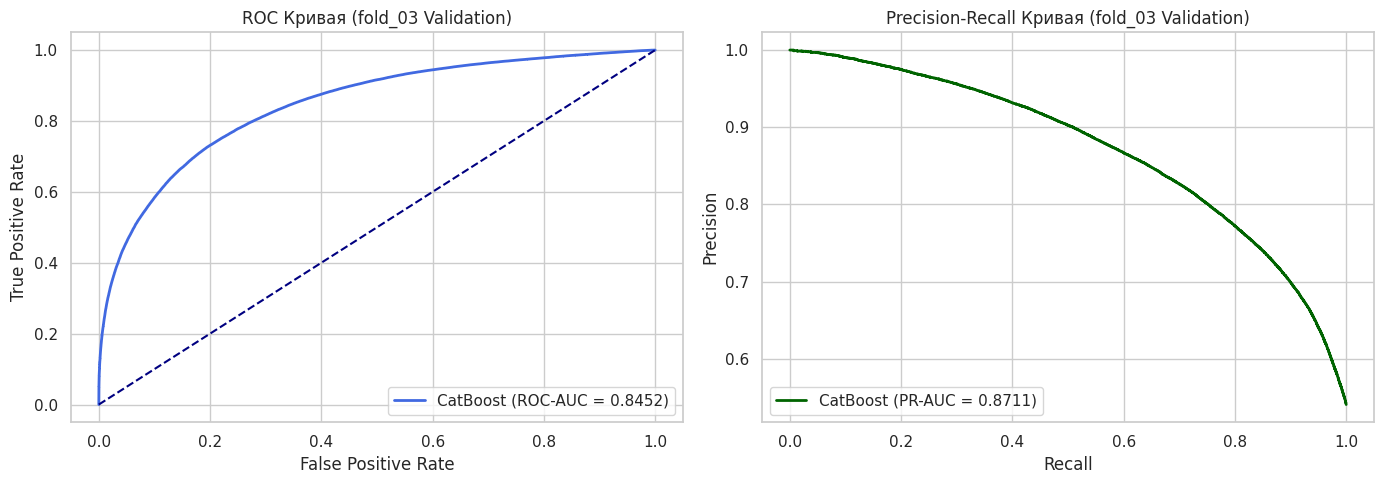

In [3]:
y_true = oof_df.filter(pl.col("anchor_date") == oof_df["anchor_date"].max())["target_bin"].to_numpy()
y_pred_prob = oof_df.filter(pl.col("anchor_date") == oof_df["anchor_date"].max())["pred_proba"].to_numpy()

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
prec, rec, _ = precision_recall_curve(y_true, y_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color="royalblue", lw=2, label=f"CatBoost (ROC-AUC = 0.8452)")
axes[0].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
axes[0].set_title("ROC Кривая (fold_03 Validation)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

# PR Curve
axes[1].plot(rec, prec, color="darkgreen", lw=2, label=f"CatBoost (PR-AUC = 0.8711)")
axes[1].set_title("Precision-Recall Кривая (fold_03 Validation)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

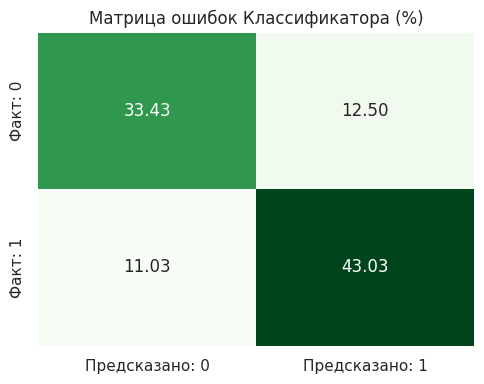

In [4]:
# Матрица ошибок при пороге 0.5
y_pred_bin = (y_pred_prob >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred_bin)
cm_pct = cm / len(y_true) * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_pct, annot=True, fmt=".2f", cmap="Greens", ax=ax, cbar=False,
            xticklabels=["Предсказано: 0", "Предсказано: 1"],
            yticklabels=["Факт: 0", "Факт: 1"])
plt.title("Матрица ошибок Классификатора (%)")
plt.tight_layout()
plt.show()

## 3. Нативная Важность Признаков (CatBoost Feature Importance)

Топ-15 самых важных признаков по версии CatBoost:
shape: (15, 2)
┌──────────────────────────────┬────────────┐
│ feature                      ┆ importance │
│ ---                          ┆ ---        │
│ str                          ┆ f64        │
╞══════════════════════════════╪════════════╡
│ to_ord_sum_90d               ┆ 26.081847  │
│ active_days_30d              ┆ 7.059717   │
│ to_ord_sum_60d               ┆ 6.875594   │
│ days_since_last_order        ┆ 3.198295   │
│ days_since_last_cart         ┆ 3.013717   │
│ …                            ┆ …          │
│ days_since_last_positive_gmv ┆ 1.927168   │
│ searches_sum_30d             ┆ 1.678246   │
│ order_conversion_rate_90d    ┆ 1.6573     │
│ to_ord_mean_90d              ┆ 1.622105   │
│ searches_mean_90d            ┆ 1.247739   │
└──────────────────────────────┴────────────┘


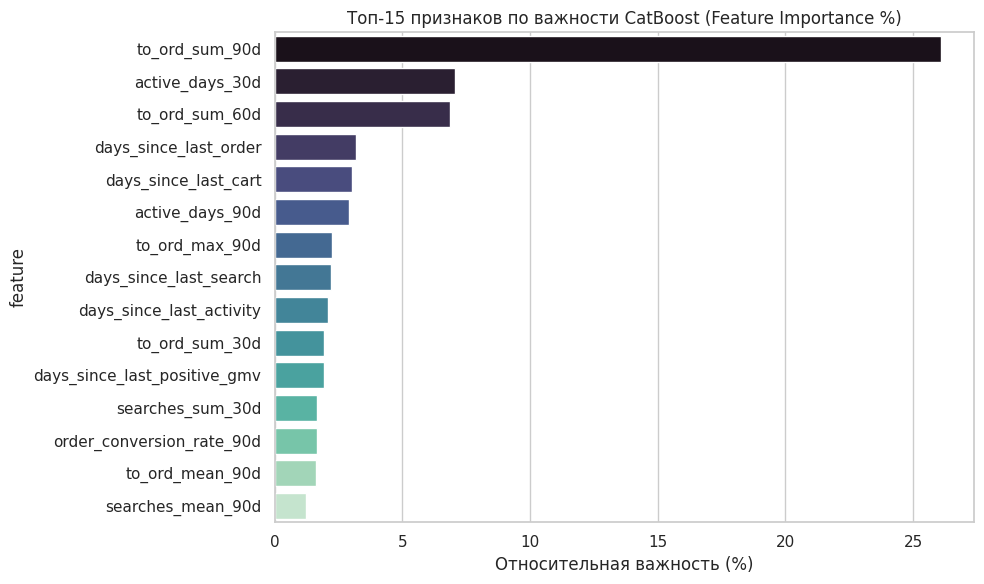

In [5]:
f03 = read_fold(FEATURES_DIR, "fold_03")
feature_cols = get_feature_columns(f03)
imp_df = get_catboost_feature_importance(model, feature_cols)

print("Топ-15 самых важных признаков по версии CatBoost:")
print(imp_df.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=imp_df.head(15).to_pandas(), x="importance", y="feature", palette="mako", hue="feature", legend=False, ax=ax)
ax.set_title("Топ-15 признаков по важности CatBoost (Feature Importance %)")
ax.set_xlabel("Относительная важность (%)")
plt.tight_layout()
plt.show()

## 4. SHAP Анализ (SHAP Values & Summary Plot)

Интерпретируемость решений CatBoost с помощью значений Шепли (SHAP).

C:\Users\egorg\AppData\Local\Temp\ipykernel_24168\2475462623.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_sample, feature_names=feature_cols, max_display=15, show=False)


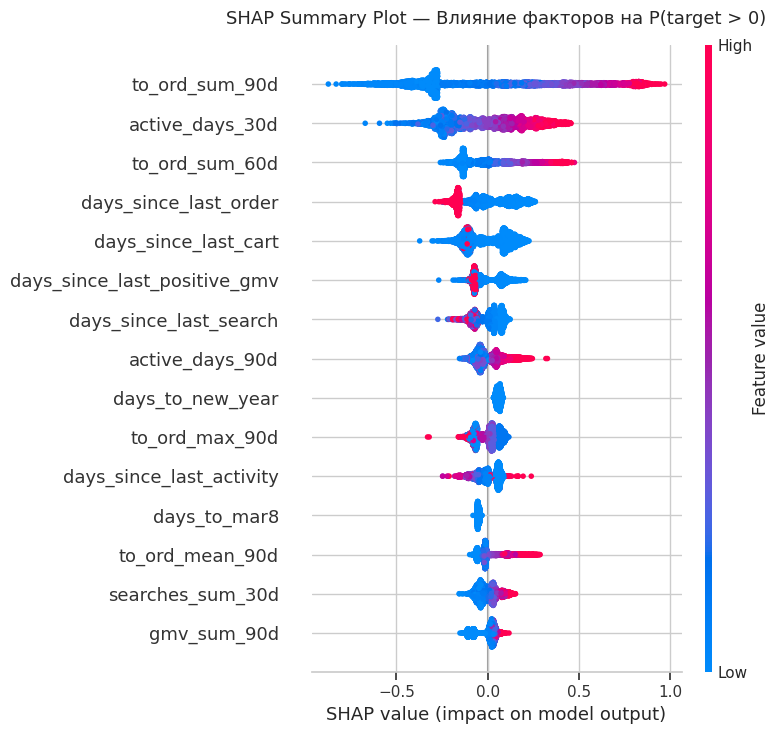

In [6]:
# Выбор случайной подвыборки в 5 000 юзеров для быстрого и точного SHAP-расчета
np.random.seed(42)
sample_indices = np.random.choice(len(f03), size=5000, replace=False)
X_sample = f03.select(feature_cols).to_numpy()[sample_indices]

shap_vals, explanation = compute_shap_values(model, X_sample, feature_cols)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_sample, feature_names=feature_cols, max_display=15, show=False)
plt.title("SHAP Summary Plot — Влияние факторов на P(target > 0)", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [8]:
# Сохранение out-of-fold предсказаний вероятностей для 2-го этапа (Регрессора)
oof_path = FEATURES_DIR + "/oof_classifier_probas.parquet"
oof_df.write_parquet(oof_path)
print(f"OOF предсказания классификатора сохранены в {oof_path} (Всего строк: {len(oof_df):,})")

OOF предсказания классификатора сохранены в data/v2/features/oof_classifier_probas.parquet (Всего строк: 750,000)
